# Part II.1 — Descriptive Statistics
Summarize the distribution and shape of each feature.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET_COL = 'Attrition'
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 13})

import os
os.makedirs("results", exist_ok=True)

In [ ]:
df_raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df_raw.copy()

cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df[TARGET_COL] = df[TARGET_COL].map({'Yes': 1, 'No': 0})
df = df.drop_duplicates(keep='first').reset_index(drop=True)

num_cols = df.select_dtypes(include=np.number).columns.drop(TARGET_COL).tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
attrition_rate = df[TARGET_COL].mean() * 100

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols | Attrition rate: {attrition_rate:.2f}%")

## 2.1 Descriptive statistics

### 2.1.1 Numerical features summary

In [36]:
desc_num = df[num_cols].describe().T
desc_num['skewness'] = df[num_cols].skew()
desc_num['kurtosis'] = df[num_cols].kurtosis()
desc_num['cv'] = (desc_num['std'] / desc_num['mean']).round(4)
desc_num = desc_num.round(3)
desc_num

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv
Age,1470.0,36.924,9.135,18.0,30.0,36.0,43.00,60.0,0.413,-0.404,0.247
DailyRate,1470.0,802.486,403.509,102.0,465.0,802.0,1157.00,1499.0,-0.004,-1.204,0.503
DistanceFromHome,1470.0,9.193,8.107,1.0,2.0,7.0,14.00,29.0,0.958,-0.225,0.882
Education,1470.0,2.913,1.024,1.0,2.0,3.0,4.00,5.0,-0.290,-0.559,0.352
EnvironmentSatisfaction,1470.0,2.722,1.093,1.0,2.0,3.0,4.00,4.0,-0.322,-1.203,0.402
HourlyRate,1470.0,65.891,20.329,30.0,48.0,66.0,83.75,100.0,-0.032,-1.196,0.308
JobInvolvement,1470.0,2.730,0.712,1.0,2.0,3.0,3.00,4.0,-0.498,0.271,0.261
JobLevel,1470.0,2.064,1.107,1.0,1.0,2.0,3.00,5.0,1.025,0.399,0.536
JobSatisfaction,1470.0,2.729,1.103,1.0,2.0,3.0,4.00,4.0,-0.330,-1.222,0.404
MonthlyIncome,1470.0,6502.931,4707.957,1009.0,2911.0,4919.0,8379.00,19999.0,1.370,1.005,0.724


In [37]:
desc_num.to_csv("results/descriptive_numerical.csv")

### 2.1.2 Distribution shape classification

In [38]:
shape_summary = []
for col in num_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        shape = 'symmetric'
    elif skew > 1:
        shape = 'right_skewed'
    elif skew < -1:
        shape = 'left_skewed'
    else:
        shape = 'slightly_skewed'
    shape_summary.append({'feature': col, 'skewness': round(skew, 3), 'shape': shape})

shape_df = pd.DataFrame(shape_summary).sort_values('skewness', ascending=False)
shape_df

,feature,skewness,shape
21,YearsSinceLastPromotion,1.984,right_skewed
13,PerformanceRating,1.922,right_skewed
19,YearsAtCompany,1.765,right_skewed
9,MonthlyIncome,1.370,right_skewed
16,TotalWorkingYears,1.117,right_skewed
11,NumCompaniesWorked,1.026,right_skewed
7,JobLevel,1.025,right_skewed
15,StockOptionLevel,0.969,slightly_skewed
2,DistanceFromHome,0.958,slightly_skewed
20,YearsInCurrentRole,0.917,slightly_skewed


### 2.1.3 Categorical features frequency

In [39]:
for col in cat_cols:
    freq = df[col].value_counts(normalize=True).round(4)*100
    freq.name = f"{col} (%)"
    display(freq.to_frame())

,BusinessTravel (%)
BusinessTravel,
Travel_Rarely,70.95
Travel_Frequently,18.84
Non-Travel,10.20


,Department (%)
Department,
Research & Development,65.37
Sales,30.34
Human Resources,4.29


,EducationField (%)
EducationField,
Life Sciences,41.22
Medical,31.56
Marketing,10.82
Technical Degree,8.98
Other,5.58
Human Resources,1.84


,Gender (%)
Gender,
Male,60.0
Female,40.0


,JobRole (%)
JobRole,
Sales Executive,22.18
Research Scientist,19.86
Laboratory Technician,17.62
Manufacturing Director,9.86
Healthcare Representative,8.91
Manager,6.94
Sales Representative,5.65
Research Director,5.44
Human Resources,3.54


,MaritalStatus (%)
MaritalStatus,
Married,45.78
Single,31.97
Divorced,22.24


,OverTime (%)
OverTime,
No,71.7
Yes,28.3


### 2.1.4 Target variable analysis

In [40]:
attrition_rate = df[TARGET_COL].mean()*100
counts = df[TARGET_COL].value_counts()
imbalance_ratio = counts[0]/counts[1]

pd.DataFrame({
    'metric': ['Total Employees', 'Stayed', 'Left', 'Attrition Rate', 'Imbalance Ratio'],
    'value':  [len(df), counts[0], counts[1], round(attrition_rate, 2), round(imbalance_ratio, 2)]
})

,metric,value
0,Total Employees,1470.00
1,Stayed,1233.00
2,Left,237.00
3,Attrition Rate,16.12
4,Imbalance Ratio,5.20


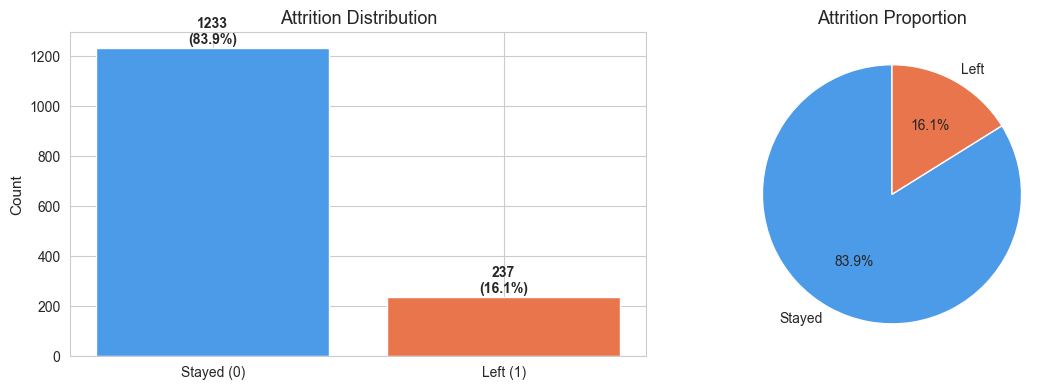

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Stayed (0)', 'Left (1)'], counts.values, color=['#4C9BE8', '#E8754C'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title(f"Attrition Distribution")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=['Stayed', 'Left'], autopct='%1.1f%%',
            colors=['#4C9BE8', '#E8754C'], startangle=90)
axes[1].set_title("Attrition Proportion")

plt.tight_layout()
plt.savefig("results/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()